In [316]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)

theme_set(
    theme_classic(base_size = 12)
)
source('./plot_data.R')

In [318]:
final_iso_tb<- read.table("../data/2_final_iso_tb.tsv", sep = "\t", header = T)
length(unique(final_iso_tb$gene_id))
dim(final_iso_tb)[1]

# final number of annotated isoforms: 6292
# final number of annotated genes: 6016

[1] 6016

[1] 6292

In [322]:
mcolors <- c("#B25D91FF", "#5E8C61FF", "#FFC857FF")
mcolors<- c(mcolors, "grey")
names(mcolors) <- c('canonical', 'downstream', 'antisense', 'Not sig')
mcolors_withsig = c(mcolors, "gray")
names(mcolors_withsig)<- c(names(mcolors), "not sig")

mcol <- c("#80b1d3", "#fb8072", "grey")
names(mcol) <- c("Down in MUT", "Up in MUT", "Not sig")

In [113]:
mature_all<- '../data/rna/matureRNA/isoquant/250925_teloprime_tx_alignment_isoform_counts.tsv'
count_all<- read.table(mature_all, header = TRUE, sep = "\t")

count_all<- count_all %>% 
    mutate(iso_id = str_split_i(isoform, ":", 1)) %>% 
    mutate(gene_id = str_split_i(iso_id, "_", 1)) %>%
    mutate(feature_id = str_split_i(isoform, ":", 2)) %>% 
    mutate(iso = paste0(isoform, "_", gene_id)) %>%
    select(iso, ys18_rep1, ys18_rep2, ys18_rep3, ym209_rep1, ym209_rep2, ym209_rep3) %>% 
    arrange(iso) %>% 
    column_to_rownames(var= "iso")

colnames(count_all)<- c("WT rep1", "WT rep2",  "WT rep3", "MUT rep1", "MUT rep2",  "MUT rep3")
tpm_all<- countToTPM(count_all, normalize_by_len = FALSE)

write.table(x = count_all, file = '../data/7_mature_rna_count.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)
write.table(x = tpm_all, file = '../data/7_mature_rna_tpm.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)

In [114]:
mature_tx<- '../data/rna/matureRNA/isoquant/250921_teloprime_tx_alignment_annot_by_tss_isoform_counts.tsv'
count<- read.table(mature_tx, header = TRUE, sep = "\t")

# reformat to same output with flair
count<- count %>% 
    mutate(iso_id = str_split_i(isoform, ":", 1)) %>% 
    mutate(gene_id = str_split_i(iso_id, "_", 1)) %>%
    mutate(iso = paste0(isoform, "_", gene_id)) %>% 
    select(iso, ys18_rep1, ys18_rep2, ys18_rep3, ym209_rep1, ym209_rep2, ym209_rep3) %>% 
    arrange(iso) %>% 
    column_to_rownames(var= "iso")

colnames(count)<- c("WT rep1", "WT rep2",  "WT rep3", "MUT rep1", "MUT rep2",  "MUT rep3")
RPK = count_all/1000
sc_factor = colSums(RPK)/ 1e6
tpm<- countToTPM(count, normalize_by_len = FALSE, scaling_factor = sc_factor)

write.table(x = count, file = '../data/7_mature_rna_tss_count.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)
write.table(x = tpm, file = '../data/7_mature_rna_tss_tpm.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)

## DESeq2 for differential gene expression

In [345]:
count<- read.table('../data/7_mature_rna_tss_count.tsv', header = T, row.names = 1, sep = '\t')
tpm<- read.table('../data/7_mature_rna_tss_tpm.tsv', header = T, row.names = 1, sep = '\t')


smallestGroupSize = 2
smallestCount = 10
keep <- rowSums(count >= smallestCount) >= smallestGroupSize
keep %>% table()
count<- count[keep, ]
tpm<-tpm[keep,]
n_genes<- length(str_split_i(rownames(tpm), ":", 1) %>% sort() %>% unique())
paste0("number of genes : ", n_genes) 
paste0("number of isoforms: ", dim(tpm)[1])

.
FALSE  TRUE 
 9054  8440 

[1] "number of genes : 5031"

[1] "number of isoforms: 8440"

In [346]:
coldata = data.frame(condition = str_split_i(colnames(count), "\\.", 1), batch = rep(1, ncol(count)))
coldata

rownames(coldata) = colnames(count)

library("DESeq2")
dds <- DESeqDataSetFromMatrix(countData = count,
                              colData = coldata,
                              design = ~ condition)
dds
dds$condition <- relevel(dds$condition, ref = "WT")

dds <- DESeq(dds)
res <- results(dds)
vsd <- vst(dds)
resLFC <- lfcShrink(dds, coef="condition_MUT_vs_WT", type="apeglm")

condition,batch
<chr>,<dbl>
WT,1
WT,1
WT,1
MUT,1
MUT,1
MUT,1


Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


class: DESeqDataSet 
dim: 8440 6 
metadata(1): version
assays(1): counts
rownames(8440): AAC1:canonical_AAC1 AAC1:downstream_AAC1 ...
  snR8:canonical_snR8 snR9:canonical_snR9
rowData names(0):
colnames(6): WT.rep1 WT.rep2 ... MUT.rep2 MUT.rep3
colData names(2): condition batch

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



In [347]:
de_df<- analyzeDESeq(res, resLFC, final_iso_tb$gene_id, padj_cutoff = 0.05, log2fc_cutoff = 0.5, annot_down = 3, annot_up = 3)
de_df$class= final_iso_tb[match(de_df$gene_id, final_iso_tb$gene_id), "class"]
de_df$class<- factor(de_df$class, levels = c('low', 'medium', 'high'))
de_df$feature_id<- factor(de_df$feature_id, levels = c('canonical', 'downstream', 'antisense'))

write.table(x = de_df, file = '../data/7_mature_rna_DE_results.tsv', quote = F, sep = '\t', col.names = T, row.names = T)

In [134]:
df1<- de_df %>%
    count(class, labels, name = 'total_per_label') %>% left_join(count(de_df, class, name = 'total'))

df2<- de_df %>%
    count(labels, feature_id, class) %>% 
    left_join(df1, by = join_by(labels, class)) %>% 
    mutate(p_per_label = n/total_per_label, p = n/total)

iso_levels <- df2 %>%
    filter(labels != "Not sig", class == "low") %>% 
    select(feature_id, labels, p) %>% 
    pivot_wider(names_from = labels, values_from = p) %>% 
    mutate(delta = `Up in MUT` - `Down in MUT`) %>% arrange(-delta) %>% 
    pull(feature_id)

write.table(df2 %>% select(class, feature_id, labels, n, total_per_label, total, p_per_label, p),
          '../data/7_mature_rna_DE_fraction_by_expr.tsv', quote = F, sep = '\t', col.names = T, row.names = F)

Joining with `by = join_by(class)`


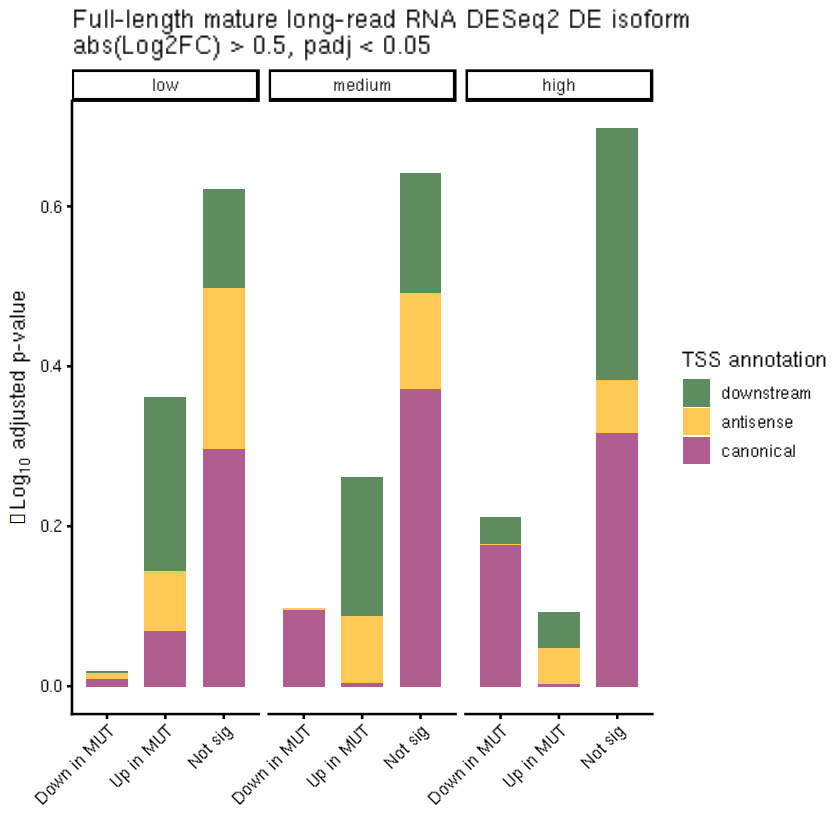

In [135]:
p1<- df2 %>%
    mutate(feature_id = factor(feature_id, levels = iso_levels),
           labels = factor(labels, levels = c("Down in MUT", "Up in MUT", "Not sig"))) %>% 
    ggplot(aes(x = labels, y = p, fill = feature_id)) +
    geom_bar(stat='identity', position = "stack", width=0.7) +
    scale_fill_manual(values = mcolors) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(x = "", y = expression(-Log[10] * " adjusted p-value"), 
         title = "Full-length mature long-read RNA DESeq2 DE isoform\nabs(Log2FC) > 0.5, padj < 0.05", fill = "TSS annotation")  +
    facet_wrap(vars(class), ncol = 3)
p1
ggsave("../figures/Supp_mature_rna_percentage_of_isoform_by_expr_with_sig.pdf", p1, width = 6, height = 3)

p2<- df2 %>%
    mutate(feature_id = factor(feature_id, levels = iso_levels),
           labels = factor(labels, levels = c("Down in MUT", "Up in MUT", "Not sig"))) %>% 
    filter(labels != "Not sig") %>% 
    ggplot(aes(x = labels, y = p, fill = feature_id)) +
    geom_bar(stat='identity', position = "stack", width=0.7) +
    scale_fill_manual(values = mcolors) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(x = "", y = expression(-Log[10] * " adjusted p-value"), 
         title = "Full-length mature long-read RNA DESeq2 DE isoform\nabs(Log2FC) > 0.5, padj < 0.05", fill = "TSS annotation") +
    facet_wrap(vars(class), ncol = 3) 

ggsave("../figures/Supp_mature_rna_percentage_of_isoform_by_expr.pdf", p2, width = 6, height = 3)

In [136]:
expr_c = unique(de_df$class)
iso_c = unique(de_df$feature_id)
de_c =  unique(de_df$labels)

for (expr in expr_c){
    for (iso in iso_c){
        for (de in de_c){
            genelist = de_df %>% filter(class == expr, feature_id == iso, labels == de) %>% pull(gene_id) %>% sort() %>% unique()
            prefix = paste0(str_replace_all(expr, " ", "_"), "_", iso, "_", str_replace_all(de, " ", "_"))
            message(prefix)
            message(length(genelist))
            write.table(genelist, paste0("../data/7_mature_rna_", prefix, ".tsv"), 
                        sep = "\t", quote = F, col.names = F, row.names = F)}
    }
}

low_downstream_Down_in_MUT

2

low_downstream_Not_sig

139

low_downstream_Up_in_MUT

243

low_canonical_Down_in_MUT

11

low_canonical_Not_sig

332

low_canonical_Up_in_MUT

78

low_antisense_Down_in_MUT

7

low_antisense_Not_sig

224

low_antisense_Up_in_MUT

83

high_downstream_Down_in_MUT

59

high_downstream_Not_sig

561

high_downstream_Up_in_MUT

81

high_canonical_Down_in_MUT

315

high_canonical_Not_sig

566

high_canonical_Up_in_MUT

5

high_antisense_Down_in_MUT

1

high_antisense_Not_sig

115

high_antisense_Up_in_MUT

79

medium_downstream_Down_in_MUT

3

medium_downstream_Not_sig

772

medium_downstream_Up_in_MUT

895

medium_canonical_Down_in_MUT

494

medium_canonical_Not_sig

1918

medium_canonical_Up_in_MUT

27

medium_antisense_Down_in_MUT

7

medium_antisense_Not_sig

617

medium_antisense_Up_in_MUT

424



In [145]:
genelist = de_df %>% filter(labels != "Not sig") %>% rownames() %>% sort() %>% unique()

write.table(x = genelist, file = "../data/7_mature_rna_all_DE_isoforms.tsv", 
            sep = "\t", quote = F, col.names = F, row.names = F)

genelist = de_df %>% filter(labels != "Not sig") %>% pull(gene_id) %>% sort() %>% unique()

write.table(x = genelist, file = "../data/7_mature_rna_all_DE_isoforms_geneid.tsv", 
            sep = "\t", quote = F, col.names = F, row.names = F)

## Combined isoform expression change and total expression change

In [350]:
gene_per_class<- de_df %>% distinct(gene_id, class) %>% count(class, name = 'total_n_gene')


labels_wide <- de_df %>%
  select(gene_id, feature_id, labels, class, log2FoldChange) %>%
  distinct(gene_id, feature_id, .keep_all = TRUE) %>%
  mutate(labels = as.character(labels)) %>%
  pivot_wider(id_cols = c(gene_id, class), names_from = feature_id,
              values_from = labels, names_prefix = "")

lfc_wide <- de_df %>%
  distinct(gene_id, feature_id, .keep_all = TRUE) %>%
  pivot_wider(id_cols = c(gene_id, class), names_from = feature_id,
              values_from = log2FoldChange, names_prefix = "lfc_")

df_joint <- left_join(labels_wide, lfc_wide, by = c("gene_id", "class"))

df_joint<- df_joint %>%
    mutate(across(any_of(c("canonical", "downstream", "antisense")), ~ replace_na(., "Not sig"))) %>% 
    mutate(
        canon_short  = recode(canonical,  "Down in MUT" = "Down", "Up in MUT" = "Up", "Not sig" = "NS"),
        down_short   = recode(downstream, "Down in MUT" = "Down", "Up in MUT" = "Up", "Not sig" = "NS"),
        anti_short   = recode(antisense,  "Down in MUT" = "Down", "Up in MUT" = "Up", "Not sig" = "NS")
    ) %>% 
    mutate(combo = paste0("C:", canon_short, " | D:", down_short, " | A:", anti_short))


# read gene expression change
gene_de<- read.table('../data/7_mature_rna_gene_DE_results.tsv', sep = '\t')
df_joint$gene_de<- gene_de[match(df_joint$gene_id, rownames(gene_de)), 'labels']
df_joint$lfc_gene_de<- gene_de[match(df_joint$gene_id, rownames(gene_de)), 'log2FoldChange']


write.table(x = df_joint, file = "../data/7_mature_rna_joint_isoform_DE_vs_gene_de_by_expr.tsv", sep = "\t", quote = F, col.names = T, row.names = F)

df<- df_joint %>% 
    count(class, combo) %>% left_join(gene_per_class, by = "class") %>% 
    mutate(frac = n/total_n_gene) %>% filter(combo != "C:NS | D:NS | A:NS")

write.table(x = df, file = "../data/7_mature_rna_joint_isoform_DE_count_by_expr.tsv", sep = "\t", quote = F, col.names = T, row.names = F)

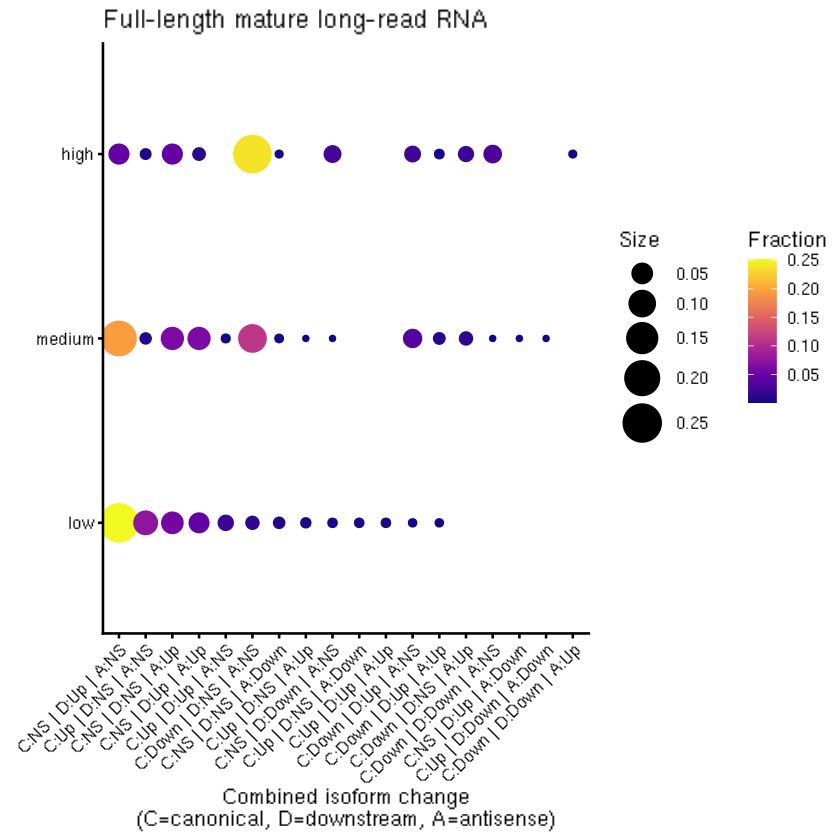

In [351]:
combo_levels = df %>% arrange(class, -frac) %>% pull(combo) %>% unique()
df$combo<- factor(df$combo, levels = combo_levels)

mcol <- rev(c("#ca0020", "#f4a582", "#92c5de"))
names(mcol) <- levels(de_df$class)


p2<- ggplot(df, aes(x = combo, y = class, size = frac, color = frac)) +
    geom_point() +
    scale_size_continuous(range = c(1, 10)) +
    scale_color_viridis_c(option = "plasma") +
    labs(x ="Combined isoform change\n(C=canonical, D=downstream, A=antisense)", 
         y = "", 
         title = "Full-length mature long-read RNA",
         size = "Fraction", color = "Fraction") +
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "right",
        legend.box = "horizontal"
    ) +
        guides(
        size = guide_legend(order = 1, title = "Size"),
        color = guide_colorbar(order = 2, title = "Fraction")
    )
p2
ggsave('../figures/Supp_mature_rna_combined_isoform_DE_by_gene_expression.pdf', p2, width = 8, height = 3)